In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from itertools import combinations
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
from scipy.stats import median_abs_deviation
import scanpy.external as sce

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

In [10]:
start = time.perf_counter()

path = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/condition_subsets/prrx_myod_filt.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata

Memory usage: current 6.79 GB, difference +5.51 GB
Total time: 0.45 seconds


AnnData object with n_obs × n_vars = 10415 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'dataset_colors'

In [11]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

sc.pp.filter_genes(adata, min_counts=10)

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# save normalized counts
adata.layers['norm_counts'] = adata.X.copy()

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

filtered out 5083 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 10415 × 23619
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'dataset_colors', 'log1p'
    layers: 'raw_counts', 'norm_counts', 'log_norm'

In [12]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:00)
computing score 'G2M_score'
    finished (0:00:00)
CPU times: user 1.1 s, sys: 585 ms, total: 1.68 s
Wall time: 1.7 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,S_score,G2M_score,phase
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.00,NaN,NaN,NaN,Hybrid,...,5.902633,1.939942,2957.0,7.992269,15.716183,False,False,-0.577489,4.668754,G2M
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.00,NaN,NaN,NaN,Hybrid,...,6.336826,1.986475,3957.0,8.283494,13.937025,False,False,-1.253247,-2.138491,G1
AAACCATTCCGTAATG_hybrid,0.0,1.0,24.0,PRRX1_MYOD,25.0,0.96,NaN,NaN,NaN,Hybrid,...,5.036952,2.306997,838.0,6.732211,12.635706,False,False,-0.346753,0.097943,G2M
AAACCCTGTTAACCAC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.00,NaN,NaN,NaN,Hybrid,...,5.641907,2.122357,1743.0,7.463937,13.164653,False,False,-1.070996,-1.583930,G1
AAACGAATCCCGCTTA_hybrid,0.0,0.0,24.0,PRRX1_MYOD,24.0,1.00,NaN,NaN,NaN,Hybrid,...,5.762052,3.120386,1635.0,7.400010,16.094103,False,False,0.341558,-0.437537,S


In [13]:
gdf = adata.var[['gene_type']].copy()
gdf = gdf.reset_index(names='names')

protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['names'].unique()
print(len(protein_coding))


adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

15340
filter_pass
True     14912
False     8707


extracting highly variable genes
Number of HVG: 2000


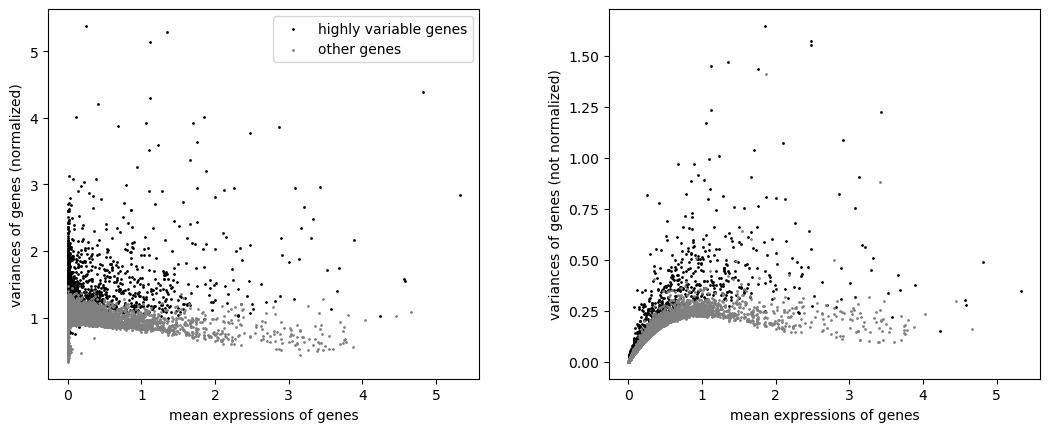

computing PCA
    with n_comps=50
    finished (0:00:13)


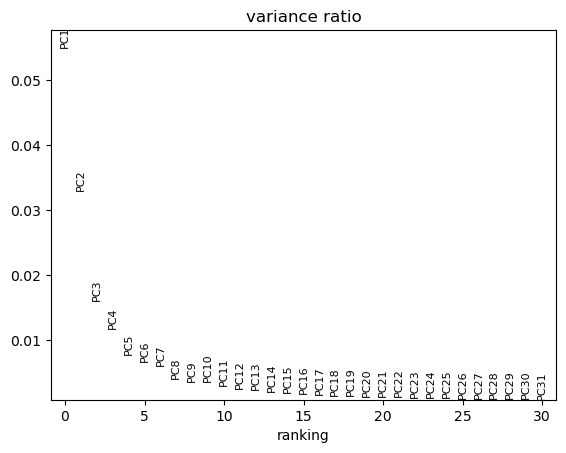

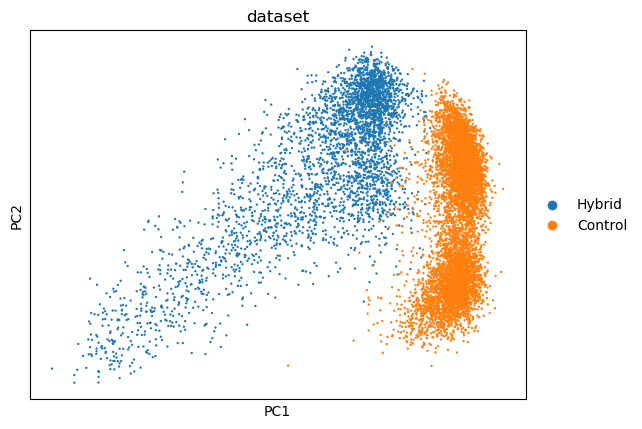

AnnData object with n_obs × n_vars = 10415 × 23619
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'hi

In [14]:
### HVGs
adata.X = adata.layers['log_norm']

sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    batch_key='dataset',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)

### PCA with 'filter_pass' genes
sc.pp.pca(
    adata,
    mask_var='filter_pass',
)

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color='dataset')

adata

2025-07-13 18:21:26,652 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-13 18:21:28,598 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-13 18:21:28,630 - harmonypy - INFO - Iteration 1 of 10
2025-07-13 18:21:30,032 - harmonypy - INFO - Iteration 2 of 10
2025-07-13 18:21:31,551 - harmonypy - INFO - Converged after 2 iterations


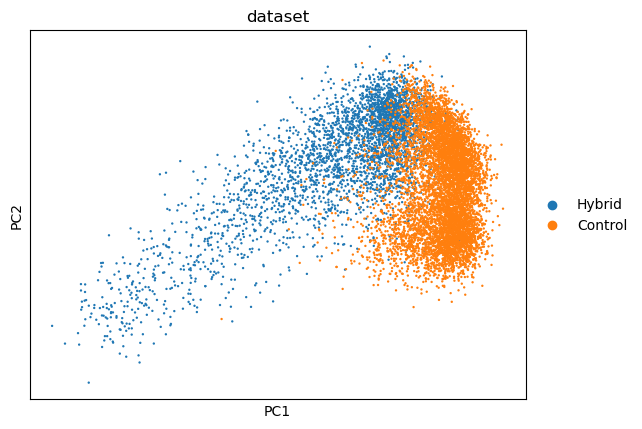

In [23]:
bdata = adata.copy()

### Harmony integration
sce.pp.harmony_integrate(bdata, key=['dataset', 'phase'])

# Save original PCA space
bdata.obsm["X_pca_original"] = bdata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting
bdata.obsm["X_pca"] = bdata.obsm["X_pca_harmony"].copy()

sc.pl.pca(bdata, color='dataset')

running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
computing neighbors
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)


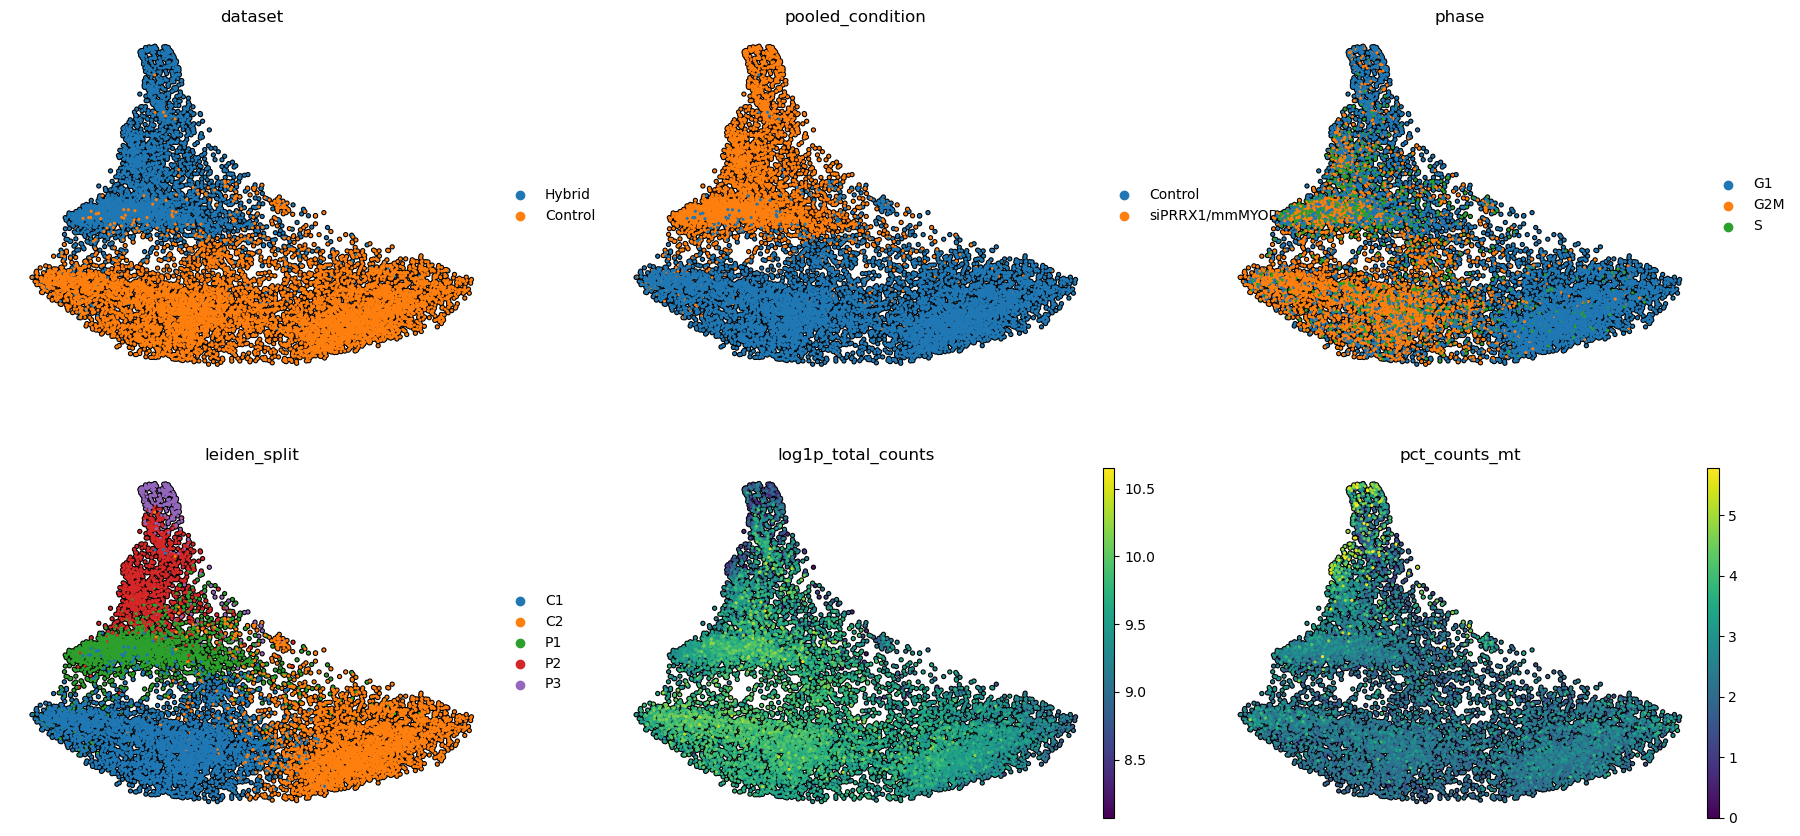

In [24]:
rsc.get.anndata_to_GPU(bdata)

rsc.pp.neighbors(
    bdata,
    use_rep='X_pca_harmony',
    n_neighbors=10,
)

rsc.tl.draw_graph(
    bdata,
)

rsc.get.anndata_to_CPU(bdata)

sc.tl.leiden(
    bdata,
    resolution=0.4,
    flavor='igraph',
)

# Cluster siprrx1 cells separately from controls
subset_hyb = bdata[bdata.obs['pooled_condition'].isin(['siPRRX1/mmMYOD1'])].copy()
rsc.get.anndata_to_GPU(subset_hyb)
rsc.pp.neighbors(subset_hyb, n_neighbors=10, use_rep='X_pca_harmony')
rsc.get.anndata_to_CPU(subset_hyb)
sc.tl.leiden(subset_hyb, resolution=0.25, flavor='igraph')


# Cluster Control cells separately from mmMYOD1
subset_ctrl = bdata[bdata.obs['pooled_condition'] == 'Control'].copy()
sc.pp.neighbors(subset_ctrl, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.leiden(subset_ctrl, resolution=0.1, flavor='igraph')


# Add back to adata as one group
bdata.obs['leiden_split'] = None
bdata.obs.loc[subset_hyb.obs_names, 'leiden_split'] = ('P' + (subset_hyb.obs['leiden'].astype(int) + 1).astype(str))
bdata.obs.loc[subset_ctrl.obs_names, 'leiden_split'] = ('C' + (subset_ctrl.obs['leiden'].astype(int) + 1).astype(str))
    

plt.rcdefaults()
sc.pl.draw_graph(
    bdata,
    color=['dataset', 'pooled_condition', 'phase', 'leiden_split', 'log1p_total_counts', 'pct_counts_mt'],
    ncols=3,
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

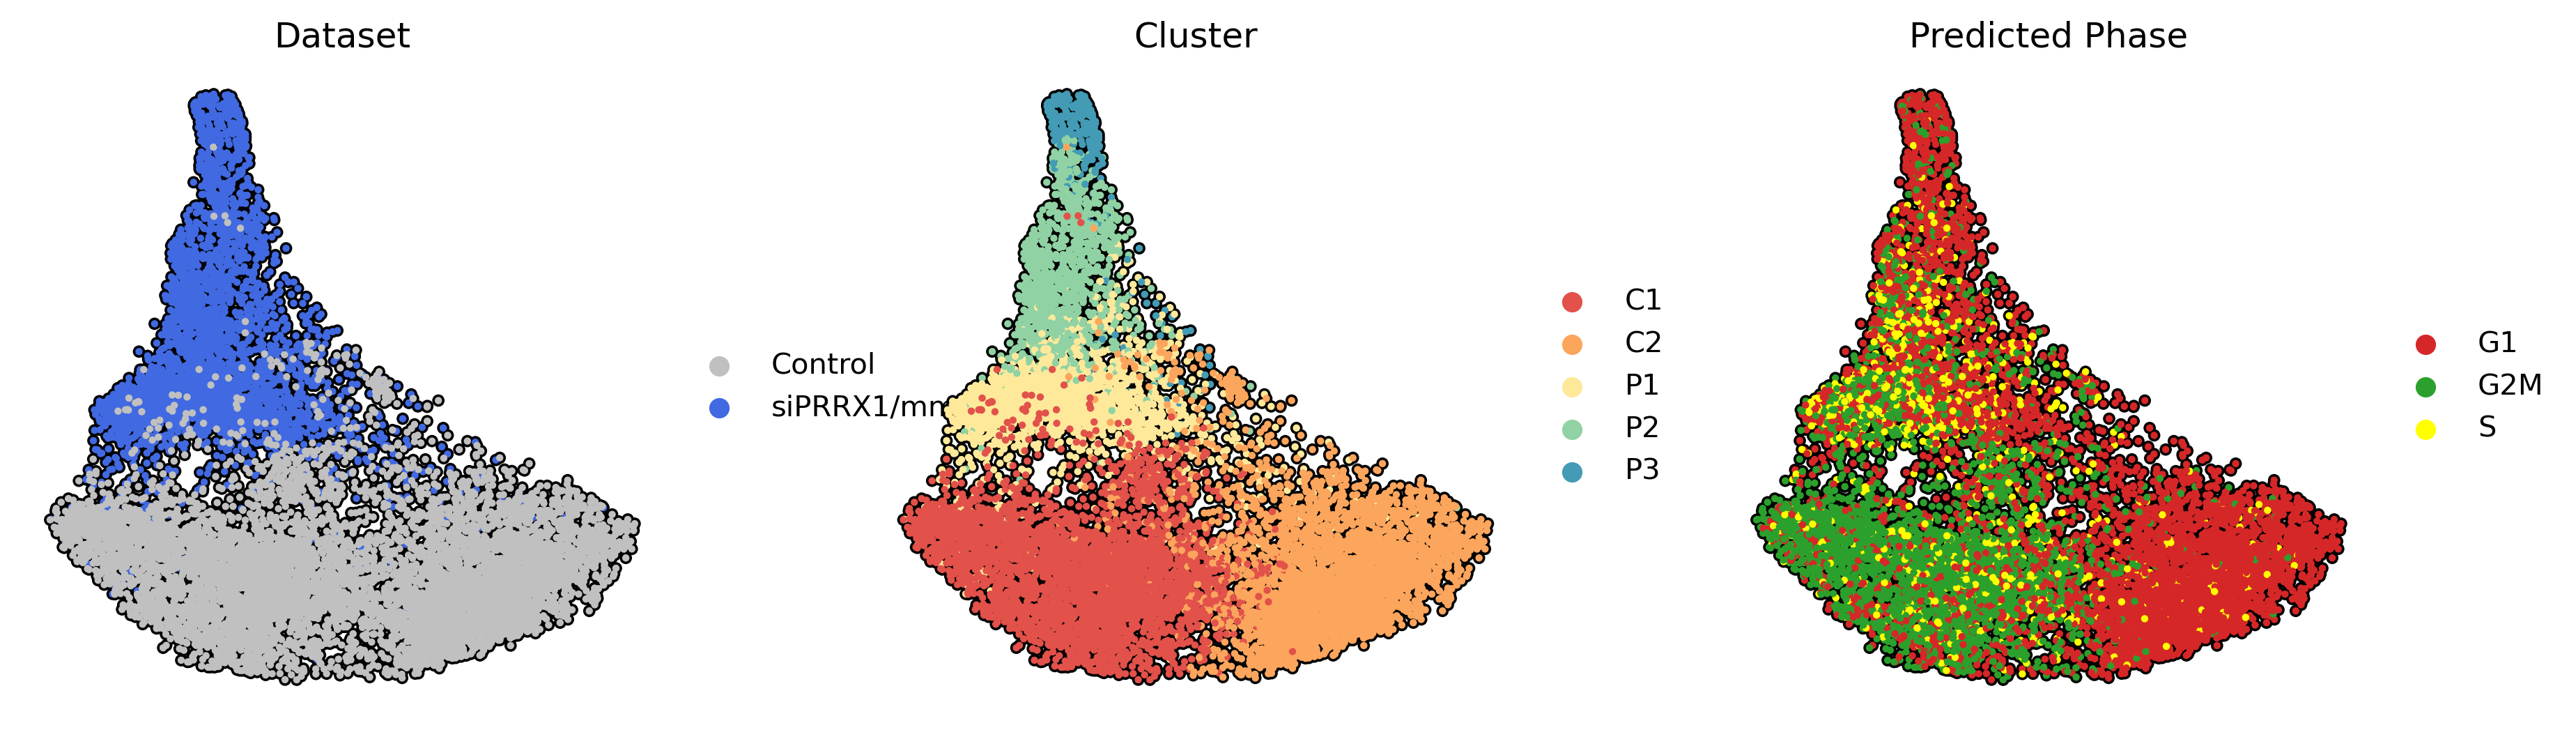

In [29]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

cluster_colors = [
    "#E2514A",
    "#FCA55D",
    "#FEE99B",
    "#90D2A4",
    "#439BB5",
]

phase_colors = [
    "tab:red",
    "tab:green",
    "yellow",
]

bdata.uns['pooled_condition_colors'] = ["silver", "royalblue"]
bdata.uns['leiden_split_colors'] = cluster_colors
bdata.uns['phase_colors'] = phase_colors


sc.pl.draw_graph(
    bdata,
    color=['pooled_condition', 'leiden_split', 'phase'],
    ncols=3,
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    title=['Dataset', 'Cluster', 'Predicted Phase'],
)

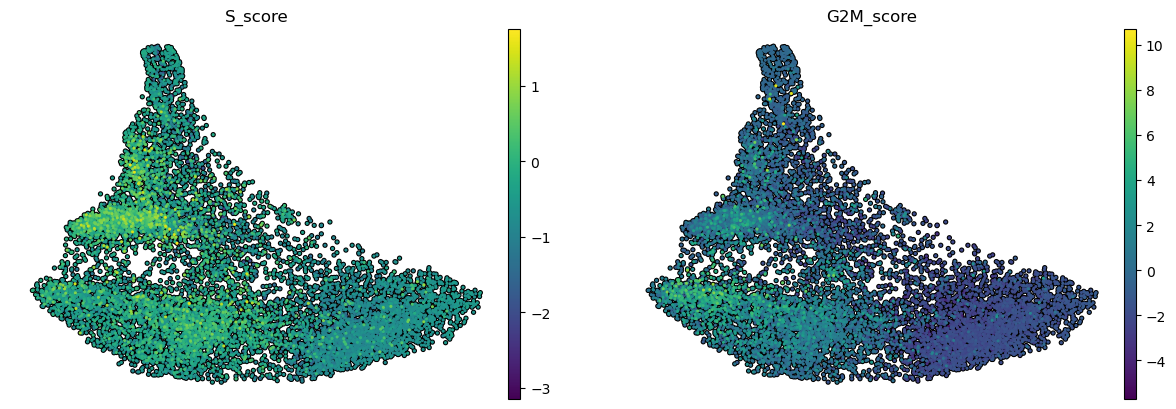

In [25]:
sc.pl.draw_graph(
    bdata,
    color=['S_score', 'G2M_score'],
    ncols=2,
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [26]:
def get_significant_DEGs(df, alpha=0.05, logfc_thresh=0.5, pct_nz_thresh=0.0):
    
    """ Filters DGE results for significant differentially expressed genes. 
    
    Params
    ------
        df (pd.DataFrame): Dataframe containing DGE results.
        alpha (float): Adjusted p-value threshold for statistical significance. Genes below this threshold are considered significant.
        logfc_thresh (float): Minimum absolute logfoldchange required for a gene to be considered significantly DE. 
        pct_nz_thresh (float): Minimum proportion of cells in the group of interest expressing the gene. Genes expressed in fewer cells than this threshold will be excluded.
    
    """
    
    tmp = df.copy()
    
    print(f"Filtering for significant DEGs (adjusted p-value < {alpha}, logfoldchange > {logfc_thresh})...")

    tmp['abs_lfc'] = tmp['logfoldchanges'].apply('abs')
    tmp = tmp[(tmp['abs_lfc'] > logfc_thresh) & (tmp['pvals_adj'] < alpha)]
    
    tmp = tmp[(tmp['pct_nz_group'] > pct_nz_thresh) | (tmp['pct_nz_reference'] > pct_nz_thresh)]
    
    if pct_nz_thresh != 0.0:
        print(f"Removed genes expressed in less than {pct_nz_thresh*100}% of cells.")
    
    print(f"N unique significant DEGs: {tmp['names'].nunique()}\n")
    
    return tmp

In [28]:
# All clusters vs the rest
sc.tl.rank_genes_groups(
    bdata, 
    groupby="leiden_split",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='deg_all_clusters',
)

deg = sc.get.rank_genes_groups_df(
    bdata, 
    group=None,
    key='deg_all_clusters',
)

print(deg.shape)

sig = get_significant_DEGs(deg, pct_nz_thresh=0.25)
sig.head()

ranking genes
    finished (0:00:19)
(118095, 8)
Filtering for significant DEGs (adjusted p-value < 0.05, logfoldchange > 0.5)...
Removed genes expressed in less than 25.0% of cells.
N unique significant DEGs: 6183



,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
0,C1,HMGB1,71.536171,1.464304,0.0,0.0,1.000000,0.973418,1.464304
1,C1,TOP2A,69.840790,3.541489,0.0,0.0,0.977260,0.381260,3.541489
2,C1,H2AZ1,69.788879,2.048010,0.0,0.0,0.999445,0.903951,2.048010
3,C1,UBE2C,66.627312,3.451062,0.0,0.0,0.935385,0.276546,3.451062
4,C1,NUSAP1,65.937096,2.933116,0.0,0.0,0.971159,0.359524,2.933116


In [30]:
filter_pass_genes = adata.var.query('filter_pass').index

tmp = sig[sig['names'].isin(filter_pass_genes)]

print(tmp['names'].nunique())
tmp.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False]).groupby('group').head()

5499


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
13,C1,SPC25,60.503502,2.999409,0.000000e+00,0.000000e+00,0.858569,0.191658,2.999409
12,C1,PBK,61.171329,2.821839,0.000000e+00,0.000000e+00,0.896007,0.234983,2.821839
16,C1,PRR11,59.758678,2.654297,0.000000e+00,0.000000e+00,0.898502,0.276252,2.654297
21,C1,ASPM,58.714024,2.652951,0.000000e+00,0.000000e+00,0.935385,0.338082,2.652951
40,C1,LMNB2,54.827072,2.621116,0.000000e+00,0.000000e+00,0.814476,0.228080,2.621116
23632,C2,SERPINE2,55.284786,2.177871,0.000000e+00,0.000000e+00,0.999106,0.893500,2.177871
23841,C2,H2BC12,23.541243,1.999844,1.543387e-122,6.085686e-121,0.406082,0.149271,1.999844
23623,C2,DCN,59.292114,1.974653,0.000000e+00,0.000000e+00,0.998807,0.887551,1.974653
23677,C2,THBS2,41.916084,1.971688,0.000000e+00,0.000000e+00,0.757305,0.406741,1.971688
23619,C2,COL1A1,68.034637,1.953584,0.000000e+00,0.000000e+00,1.000000,0.965444,1.953584
